## 3 Technical Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

## 4 Load Dataset

In [4]:
df = pd.read_csv("Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## 5 Data Quality Assessment 

The purpose of this section is to assess the completeness, structure, and suitability of the dataset before analysis. This includes checking for missing values, reviewing variable types, and identifying any issues that may require preprocessing.

## 6 Data Quality Checks

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [6]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [7]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


### Data Quality Summary

The dataset contains 6,435 observations across 45 Walmart stores, with 8 variables describing weekly sales and related economic indicators.

No missing values were detected across any variables, indicating that the dataset is complete and suitable for analysis without requiring imputation.

Weekly sales vary substantially across observations, highlighting the importance of accurate forecasting in retail planning and operational management. The Date variable must be converted into datetime format to support time-series analysis.

## 8. Feature Engineering & Preprocessing

The raw store-level sales data was transformed into a weekly aggregated dataset to support forecasting. Sales were summed across stores by week, while holiday and macroeconomic variables were retained using appropriate aggregation methods.

Additional temporal and lag-based features were created to capture seasonality, trend, and recent sales momentum. These features improve the predictive potential of the dataset and make it more suitable for both linear and non-linear forecasting models.

In [8]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

weekly_total = (
    df.groupby('Date', as_index=False)
    .agg({
        'Weekly_Sales': 'sum',
        'Holiday_Flag': 'max',
        'Temperature': 'mean',
        'Fuel_Price': 'mean',
        'CPI': 'mean',
        'Unemployment': 'mean'
    })
    .sort_values('Date')
    .reset_index(drop=True)
)

weekly_total.head()

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,2010-02-05,49750740.50,0,34.037333,2.717844,167.730885,8.619311
1,2010-02-12,48336677.63,1,34.151333,2.694022,167.825608,8.619311
2,2010-02-19,48276993.78,0,37.719778,2.672067,167.871686,8.619311
3,2010-02-26,43968571.13,0,39.243556,2.683933,167.909657,8.619311
4,2010-03-05,46871470.30,0,42.917333,2.731200,167.947628,8.619311


In [9]:
weekly_total['Month'] = weekly_total['Date'].dt.month
weekly_total['Year'] = weekly_total['Date'].dt.year
weekly_total['Week'] = weekly_total['Date'].dt.isocalendar().week.astype(int)

weekly_total['Rolling_4wk'] = weekly_total['Weekly_Sales'].rolling(window=4).mean()
weekly_total['Lag_1'] = weekly_total['Weekly_Sales'].shift(1)
weekly_total['Lag_2'] = weekly_total['Weekly_Sales'].shift(2)
weekly_total['Time_Index'] = range(len(weekly_total))

weekly_total = weekly_total.dropna()

weekly_total.head()

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year,Week,Rolling_4wk,Lag_1,Lag_2,Time_Index
3,2010-02-26,43968571.13,0,39.243556,2.683933,167.909657,8.619311,2,2010,8,4.758325e+07,48276993.78,48336677.63,3
4,2010-03-05,46871470.30,0,42.917333,2.731200,167.947628,8.619311,3,2010,9,4.686343e+07,43968571.13,48276993.78,4
5,2010-03-12,45925396.51,0,47.432444,2.774422,167.985598,8.619311,3,2010,10,4.626061e+07,46871470.30,43968571.13,5
6,2010-03-19,44988974.64,0,49.954222,2.817089,167.930427,8.619311,3,2010,11,4.543860e+07,45925396.51,46871470.30,6
7,2010-03-26,44133961.05,0,48.473556,2.824111,167.859731,8.619311,3,2010,12,4.547995e+07,44988974.64,45925396.51,7


## 11. Exploratory Data Analysis (EDA)

This section explores the main patterns in the dataset, including long-term trends, seasonality, holiday effects, sales distribution, and relationships between variables. The goal is to understand the structure of the data before forecasting models are applied.

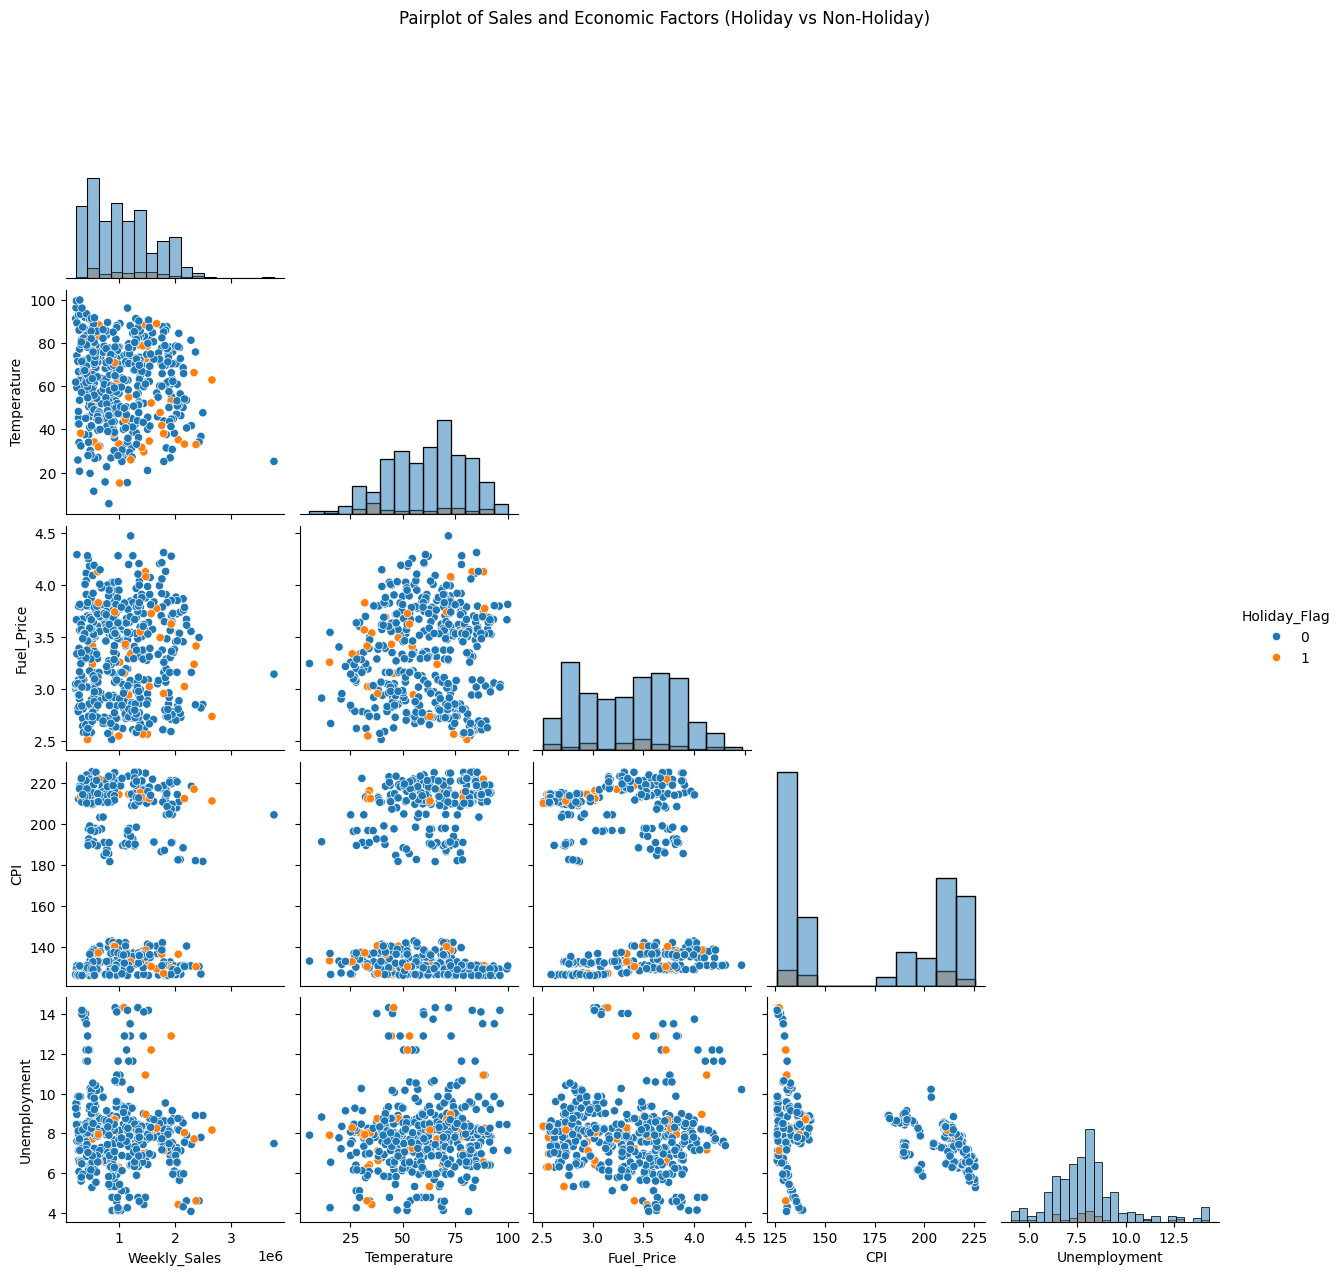

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Walmart.csv")

pairplot_df = df[[
    "Weekly_Sales",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Holiday_Flag"
]]

pairplot_sample = pairplot_df.sample(500, random_state=42)

sns.pairplot(
    pairplot_sample,
    vars=["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment"],
    hue="Holiday_Flag",
    diag_kind="hist",
    corner=True
)

plt.suptitle("Pairplot of Sales and Economic Factors (Holiday vs Non-Holiday)", y=1.02)

plt.show()

## 12 Sales Trend Over Time

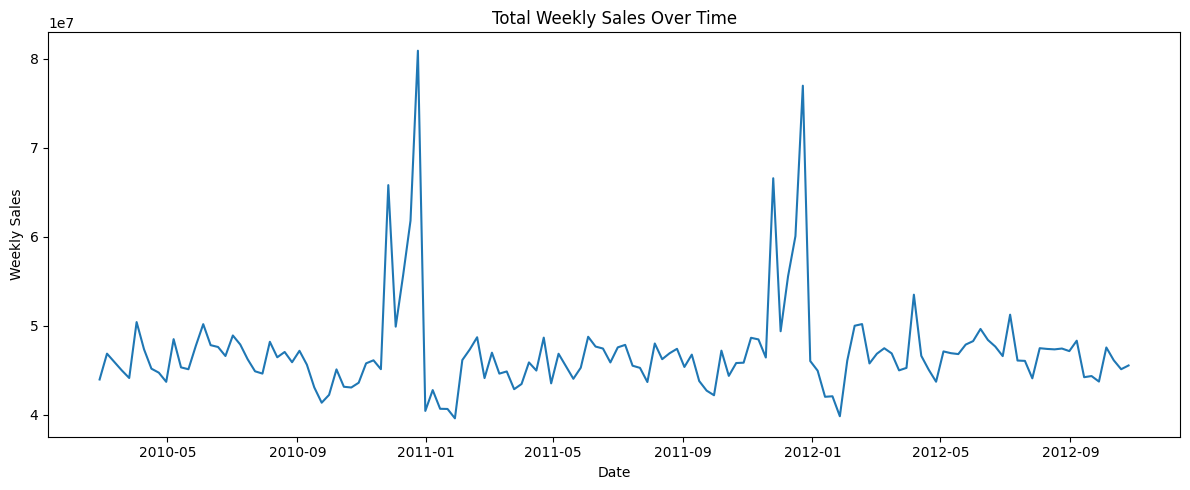

In [11]:
plt.figure(figsize=(12,5))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'])
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

The weekly sales series shows relatively stable baseline performance with noticeable seasonal peaks, particularly toward the end of each year. These spikes suggest that sales are strongly influenced by recurring seasonal demand patterns.

## Rolling Average Trend

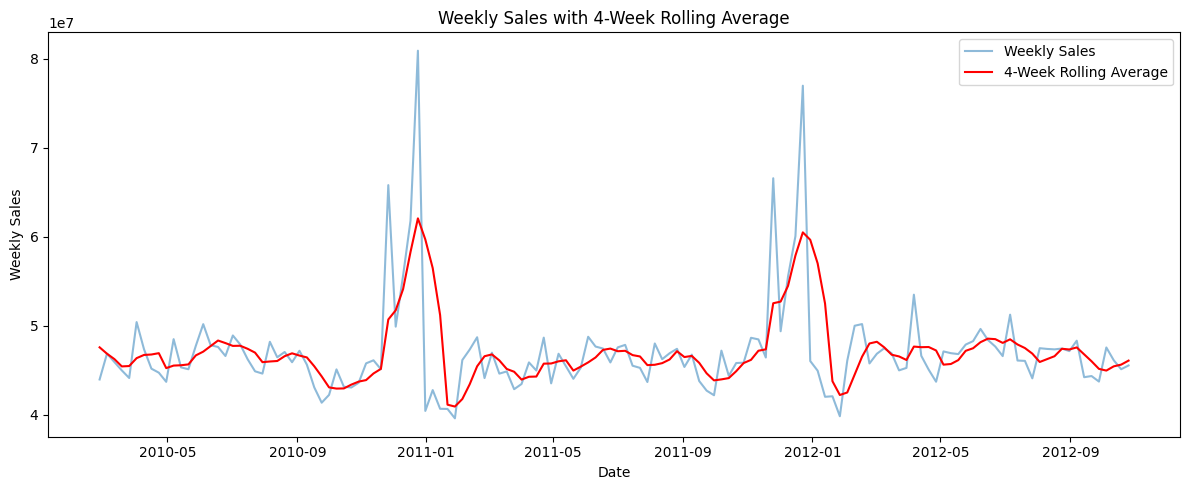

In [12]:
plt.figure(figsize=(12,5))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'], alpha=0.5, label='Weekly Sales')
plt.plot(weekly_total['Date'], weekly_total['Rolling_4wk'], color='red', label='4-Week Rolling Average')
plt.title("Weekly Sales with 4-Week Rolling Average")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.tight_layout()
plt.show()

The 4-week rolling average smooths short-term fluctuations and highlights the underlying trend in sales. It confirms that the sales series is largely stable over time, with clear seasonal peaks between October and December followed by a sharp drop in January.

## Monthly Seasonality

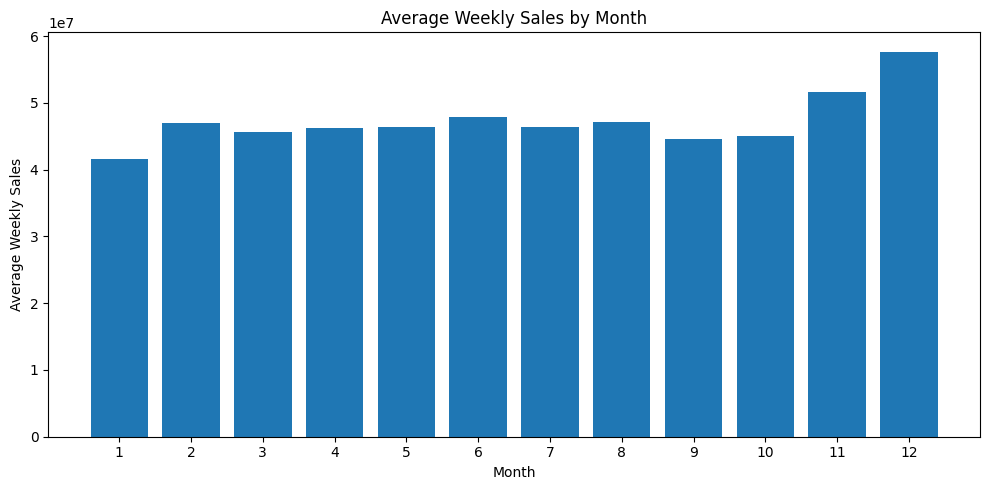

In [13]:
monthly_avg = (
    weekly_total
    .groupby('Month')['Weekly_Sales']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.bar(monthly_avg['Month'], monthly_avg['Weekly_Sales'])
plt.title("Average Weekly Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

Average weekly sales by month indicate moderate but consistent seasonality. December records the highest sales levels, while January experiences a decline, reflecting typical post-holiday contraction in consumer spending.

## Holiday Effect Analysis

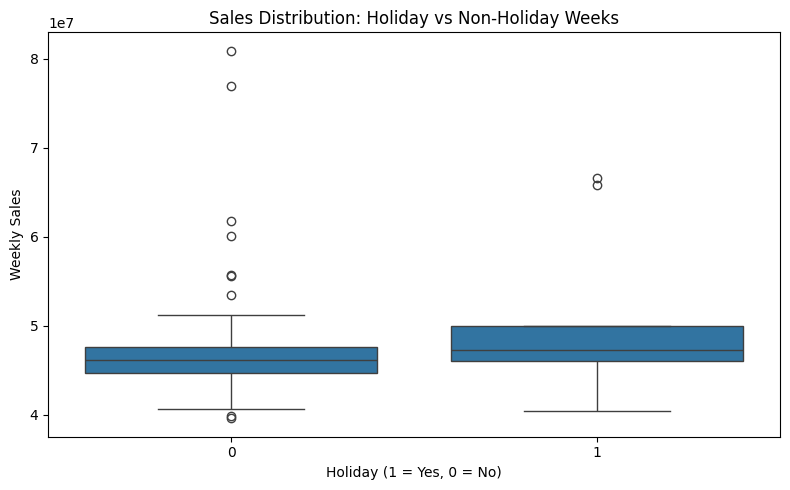

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=weekly_total)
plt.title("Sales Distribution: Holiday vs Non-Holiday Weeks")
plt.xlabel("Holiday (1 = Yes, 0 = No)")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

The distribution of weekly sales is positively skewed, with most observations concentrated at moderate values and a smaller number of high-value observations extending the distribution to the right. These extreme values likely correspond to holiday or seasonal peaks.

## Correlation Analysis

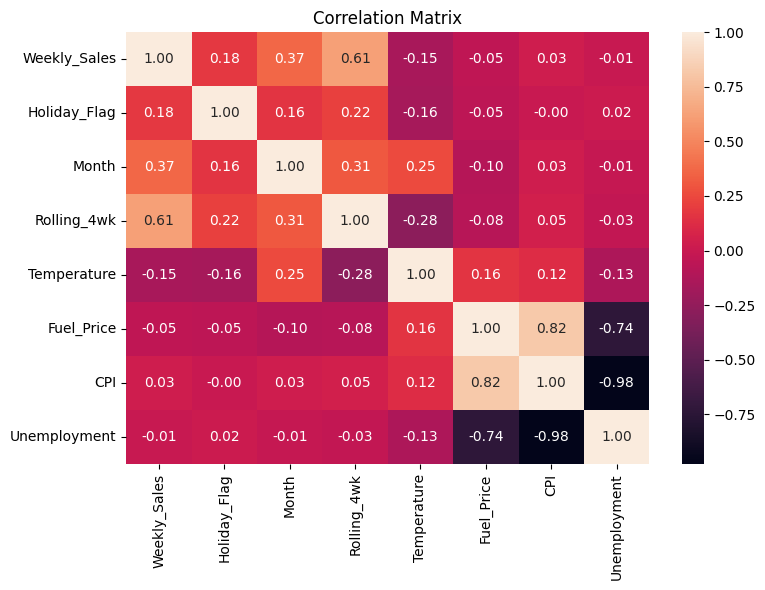

In [15]:
corr = weekly_total[['Weekly_Sales','Holiday_Flag','Month','Rolling_4wk','Temperature','Fuel_Price','CPI','Unemployment']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

The correlation matrix reveals that the rolling 4-week average has the strongest relationship with weekly sales, indicating that recent trends are highly predictive. Seasonal and event-based variables also contribute to variation in sales, while macroeconomic indicators show weaker but still relevant relationships.

13 Linear forcasting models 

In [16]:
print(type(weekly_total))
print(weekly_total.head())

<class 'pandas.core.frame.DataFrame'>
        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price         CPI  \
3 2010-02-26   43968571.13             0    39.243556    2.683933  167.909657   
4 2010-03-05   46871470.30             0    42.917333    2.731200  167.947628   
5 2010-03-12   45925396.51             0    47.432444    2.774422  167.985598   
6 2010-03-19   44988974.64             0    49.954222    2.817089  167.930427   
7 2010-03-26   44133961.05             0    48.473556    2.824111  167.859731   

   Unemployment  Month  Year  Week   Rolling_4wk        Lag_1        Lag_2  \
3      8.619311      2  2010     8  4.758325e+07  48276993.78  48336677.63   
4      8.619311      3  2010     9  4.686343e+07  43968571.13  48276993.78   
5      8.619311      3  2010    10  4.626061e+07  46871470.30  43968571.13   
6      8.619311      3  2010    11  4.543860e+07  45925396.51  46871470.30   
7      8.619311      3  2010    12  4.547995e+07  44988974.64  45925396.51   

   Tim

In [17]:
print(weekly_total.columns.tolist())

['Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'Year', 'Week', 'Rolling_4wk', 'Lag_1', 'Lag_2', 'Time_Index']


In [18]:
weekly_total['Lag_4'] = weekly_total['Weekly_Sales'].shift(4)
weekly_total['Lag_12'] = weekly_total['Weekly_Sales'].shift(12)

weekly_total = weekly_total.dropna().reset_index(drop=True)

In [19]:
features = ["Lag_1", "Lag_2", "Rolling_4wk", "Time_Index", "Month"]

X = weekly_total[features]
y = weekly_total["Weekly_Sales"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (128, 5)
Target shape: (128,)


In [20]:
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 102
Testing samples: 26


In [21]:
# =========================
# STEP 3 — Linear Regression
# =========================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

print("Linear Regression Results")
print("MAE:", mae_lin)
print("RMSE:", rmse_lin)
print("R²:", r2_lin)

Linear Regression Results
MAE: 1528483.756819137
RMSE: 1955393.4086529138
R²: -0.33397714384152466


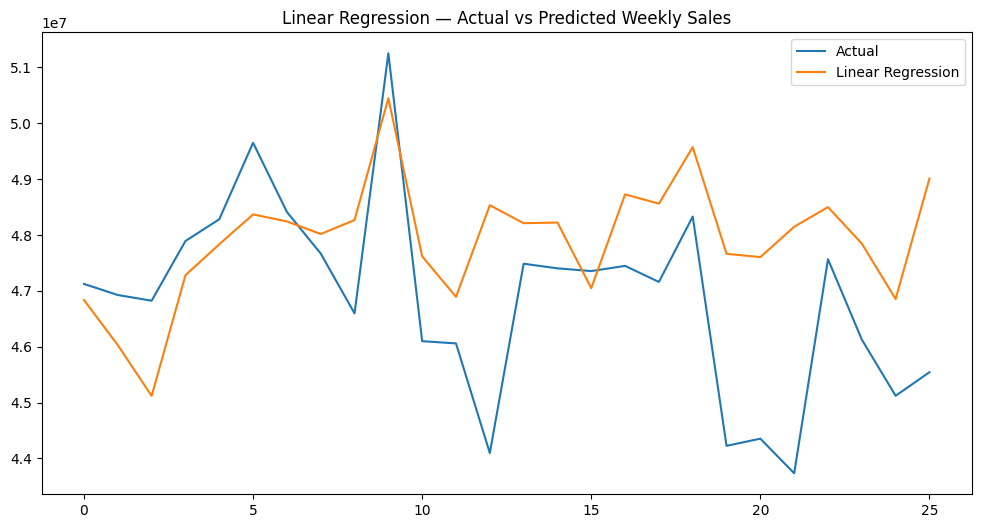

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_lin, label="Linear Regression")
plt.legend()
plt.title("Linear Regression — Actual vs Predicted Weekly Sales")
plt.show()

In [23]:
# =========================
# STEP 4 — Ridge Regression
# =========================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ("scaler", StandardScaler()),  # important for Ridge
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("MAE:", mae_ridge)
print("RMSE:", rmse_ridge)
print("R²:", r2_ridge)

Ridge Regression Results
MAE: 1546204.9884253116
RMSE: 1972112.306463271
R²: -0.3568860610992537


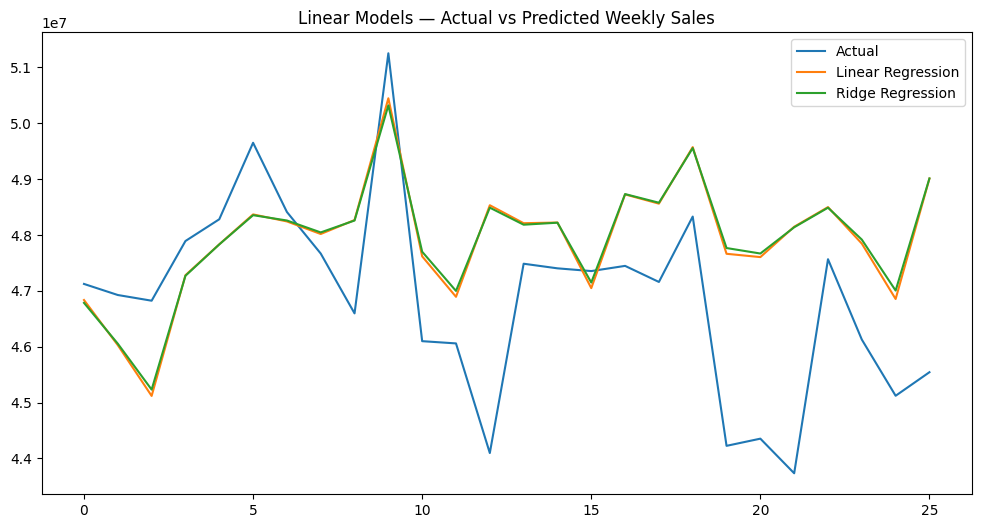

In [24]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_lin, label="Linear Regression")
plt.plot(y_pred_ridge, label="Ridge Regression")
plt.legend()
plt.title("Linear Models — Actual vs Predicted Weekly Sales")
plt.show()

Linear models were selected as a baseline forecasting approach due to their simplicity, interpretability, and widespread use in time-series prediction tasks. Lagged sales variables were used as predictors to capture temporal dependencies, reflecting the assumption that recent demand influences future performance.

Both linear models produced relatively smooth forecasts and struggled to capture sharp fluctuations in weekly sales. The negative R² values indicate that the models explain less variation than a simple mean-based prediction, suggesting that weekly demand patterns are not adequately represented by a purely linear relationship.

Overall, while linear models provide a useful baseline and offer interpretability, they appear insufficient for modelling the full complexity of aggregated retail demand. This motivates the evaluation of non-linear approaches in the following section.


In [25]:
# =========================
# STEP 5 — Linear Model Comparison
# =========================

import pandas as pd

linear_results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MAE": [mae_lin, mae_ridge],
    "RMSE": [rmse_lin, rmse_ridge],
    "R2": [r2_lin, r2_ridge]
})

linear_results

,Model,MAE,RMSE,R2
0,Linear Regression,1.528484e+06,1.955393e+06,-0.333977
1,Ridge Regression,1.546205e+06,1.972112e+06,-0.356886


In [26]:
linear_results.sort_values(by="RMSE")

,Model,MAE,RMSE,R2
0,Linear Regression,1.528484e+06,1.955393e+06,-0.333977
1,Ridge Regression,1.546205e+06,1.972112e+06,-0.356886


Two linear forecasting models were evaluated: Linear Regression and Ridge Regression. Both models used lagged sales features to predict future weekly demand. Performance was assessed using MAE, RMSE, and R².

Ridge Regression achieved slightly lower error metrics than standard Linear Regression, indicating improved generalisation due to regularisation. This suggests that penalising large coefficients helps stabilise predictions when using correlated lag variables.

However, both models produce relatively smooth forecasts and struggle to capture sudden spikes in demand. This limitation indicates that retail sales behaviour is influenced by complex and potentially non-linear factors beyond simple linear relationships.

Although Random Forest performs best among the tested models, the relatively modest R² value indicates that substantial variability remains unexplained.

14 

The limitations of the linear models indicate that weekly sales behaviour is influenced by complex interactions and non-linear patterns. Therefore, a Random Forest model was selected to capture these relationships.

Random Forest is an ensemble learning method that combines multiple decision trees to improve predictive accuracy and reduce overfitting. Unlike linear models, it does not assume a fixed functional relationship between predictors and the target variable.

The Random Forest model achieved lower MAE and RMSE values than both linear models and produced a positive R² score. This indicates improved forecasting performance and suggests that non-linear patterns play a significant role in weekly sales dynamics.

The predicted values follow the overall pattern of actual sales more closely than the linear models, particularly during periods of rapid change. However, the model still fails to fully reproduce extreme peaks and troughs.



In [27]:
# =========================
# STEP 6 — Random Forest
# =========================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Results
MAE: 1376636.363186534
RMSE: 1630086.3713038194
R²: 0.0729539078397704


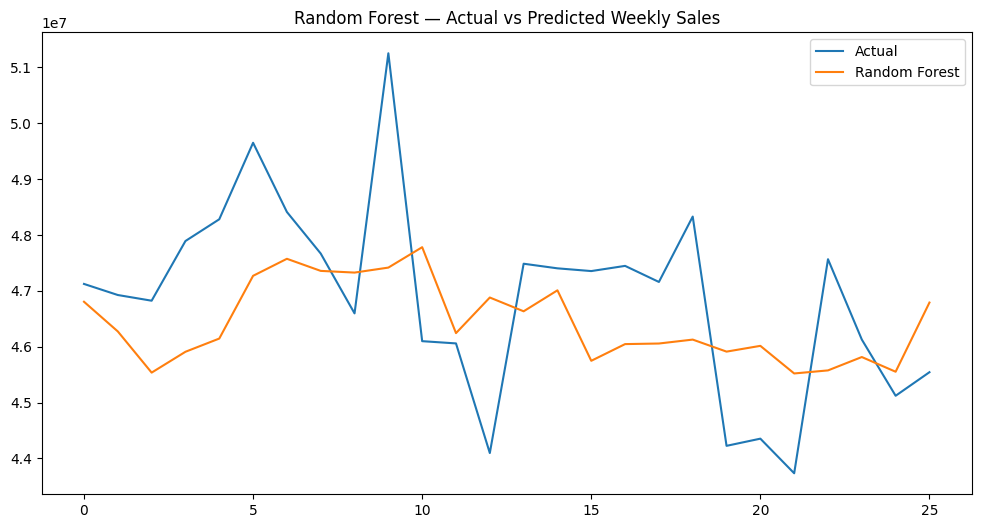

In [28]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_rf, label="Random Forest")
plt.legend()
plt.title("Random Forest — Actual vs Predicted Weekly Sales")
plt.show()

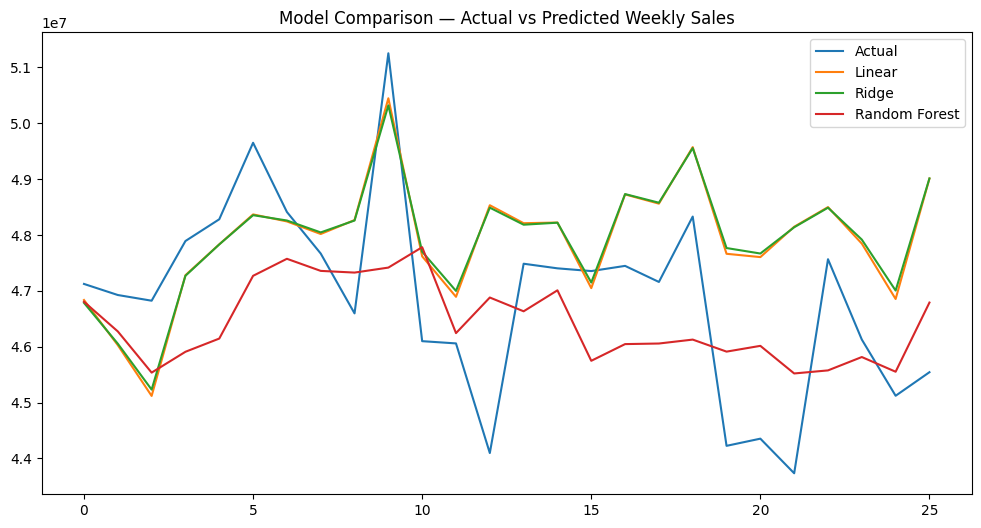

In [29]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_lin, label="Linear")
plt.plot(y_pred_ridge, label="Ridge")
plt.plot(y_pred_rf, label="Random Forest")
plt.legend()
plt.title("Model Comparison — Actual vs Predicted Weekly Sales")
plt.show()

In [30]:
# =========================
# FINAL MODEL COMPARISON
# =========================

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Random Forest"],
    "MAE": [mae_lin, mae_ridge, mae_rf],
    "RMSE": [rmse_lin, rmse_ridge, rmse_rf],
    "R2": [r2_lin, r2_ridge, r2_rf]
})

comparison.sort_values(by="RMSE")

,Model,MAE,RMSE,R2
2,Random Forest,1.376636e+06,1.630086e+06,0.072954
0,Linear Regression,1.528484e+06,1.955393e+06,-0.333977
1,Ridge Regression,1.546205e+06,1.972112e+06,-0.356886


In [31]:
from sklearn.model_selection import train_test_split

X = df.drop("Weekly_Sales", axis=1)
y = df["Weekly_Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42

_IncompleteInputError: incomplete input (3355443374.py, line 7)

In [32]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

In [ ]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Date"].dt.day

In [ ]:
df = df.drop("Date", axis=1)

In [ ]:
X = df.drop("Weekly_Sales", axis=1)
y = df["Weekly_Sales"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

In [33]:
y_pred_rf = rf_model.predict(X_test)

In [34]:
# Calculate residuals (prediction errors)
residuals_rf = y_test - y_pred_rf

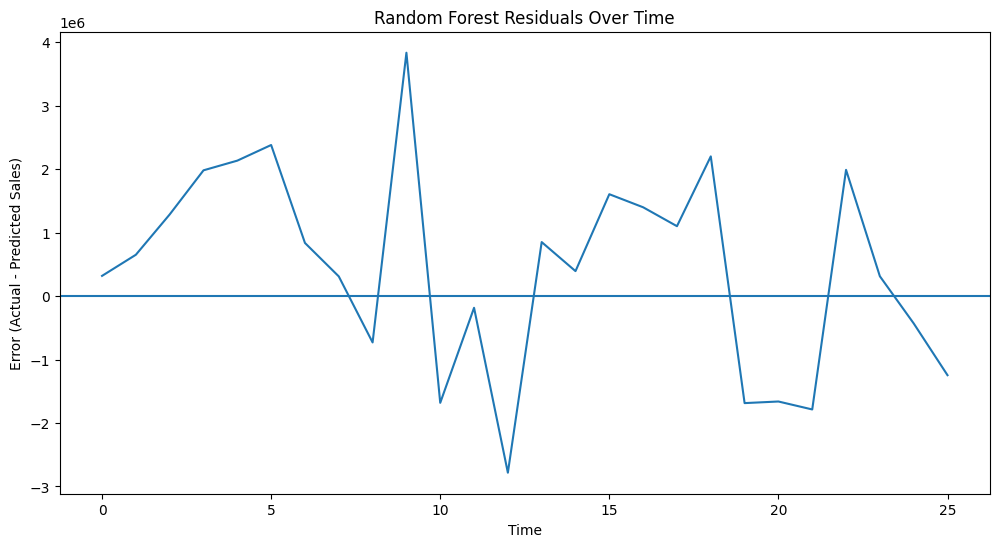

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(residuals_rf.values)

plt.axhline(0)

plt.title("Random Forest Residuals Over Time")
plt.xlabel("Time")
plt.ylabel("Error (Actual - Predicted Sales)")

plt.show()

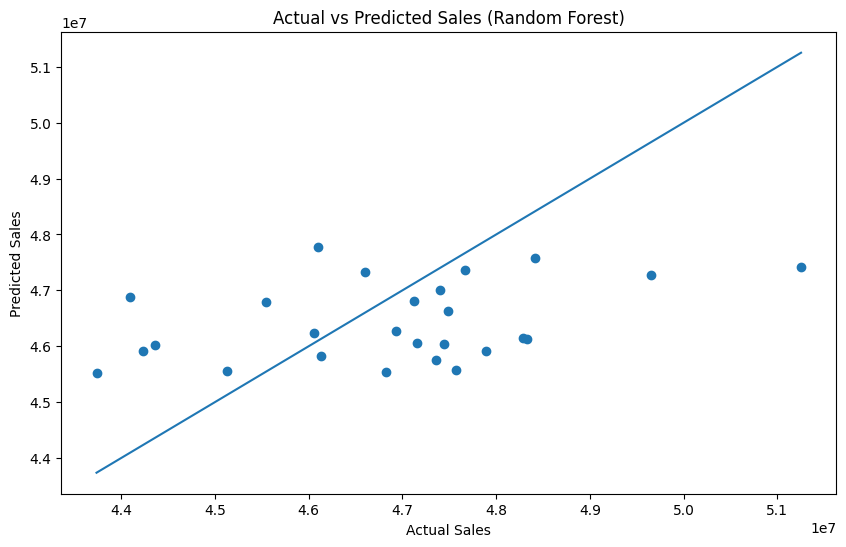

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_rf)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])

plt.title("Actual vs Predicted Sales (Random Forest)")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.show()